In [1]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from traincae import DEFAULT_PARAMS, SlidingWindowDataset
from loadData import RawDataset, preprocess_hydraulic_data, preprocess_hydraulic_synthetic_dataset, obtain_ground_truth
from findAnomalies import *
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Find anomalies on real dataset

In [2]:
### Loading the model and the dataset
unit = "VG5"
mode ="pump"

test_df = pd.read_parquet(f'./reconstructed/test_{unit}_{mode}/original_{unit}_{mode}.parquet')
reconstructed_test_df = pd.read_parquet(f'./reconstructed/test_{unit}_{mode}/reconstructed_{unit}_{mode}.parquet')
error_test = pd.read_parquet(f'./reconstructed/test_{unit}_{mode}/error_{unit}_{mode}.parquet')

scaler, threshold_df, model = load_model(unit = unit, mode = mode)

/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/matthieu/Documents/ML predictive maintenance/Project/MLPM/SERVERFILES_CAE/findAnomalies.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that 

In [3]:
faulty_df = (error_test>threshold_df)
faulty_df = filter_faulty_df(faulty_df, 130)

faulty_signals_df = get_faulty_signals(faulty_df)

target_columns = faulty_signals_df.head(40).index

print(target_columns)

Processing columns: 100%|██████████| 84/84 [00:16<00:00,  5.22it/s]

Index(['water_circ_flow', 'stat_coil_ph03_05_tmp', 'stat_coil_ph02_05_tmp',
       'stat_coil_ph01_05_tmp', 'stat_coil_ph02_06_tmp',
       'stat_coil_ph03_06_tmp', 'stat_coil_ph01_06_tmp', 'stat_magn_02_tmp',
       'stat_magn_07_tmp', 'stat_magn_05_tmp', 'stat_magn_11_tmp',
       'air_circ_hot_02_tmp', 'air_circ_hot_06_tmp', 'air_circ_hot_05_tmp',
       'air_circ_hot_03_tmp', 'air_circ_hot_01_tmp', 'air_circ_hot_04_tmp',
       'air_circ_cold_03_tmp', 'air_circ_cold_02_tmp', 'air_circ_cold_05_tmp',
       'air_circ_cold_06_tmp', 'air_circ_cold_01_tmp', 'air_circ_cold_04_tmp',
       'air_gap_negative_x_position', 'water_circ_hot_04_tmp',
       'water_circ_hot_03_tmp', 'water_circ_hot_05_tmp',
       'water_circ_hot_01_tmp', 'water_circ_hot_02_tmp', 'exc_current',
       'pump_calculated_flow', 'tot_reactivepower', 'stat_coil_ph03_04_tmp',
       'pump_pressure_diff', 'stat_coil_ph03_03_tmp', 'plant_tmp',
       'turbine_rotspeed', 'stat_coil_ph03_02_tmp', 'ph03_current',
       's

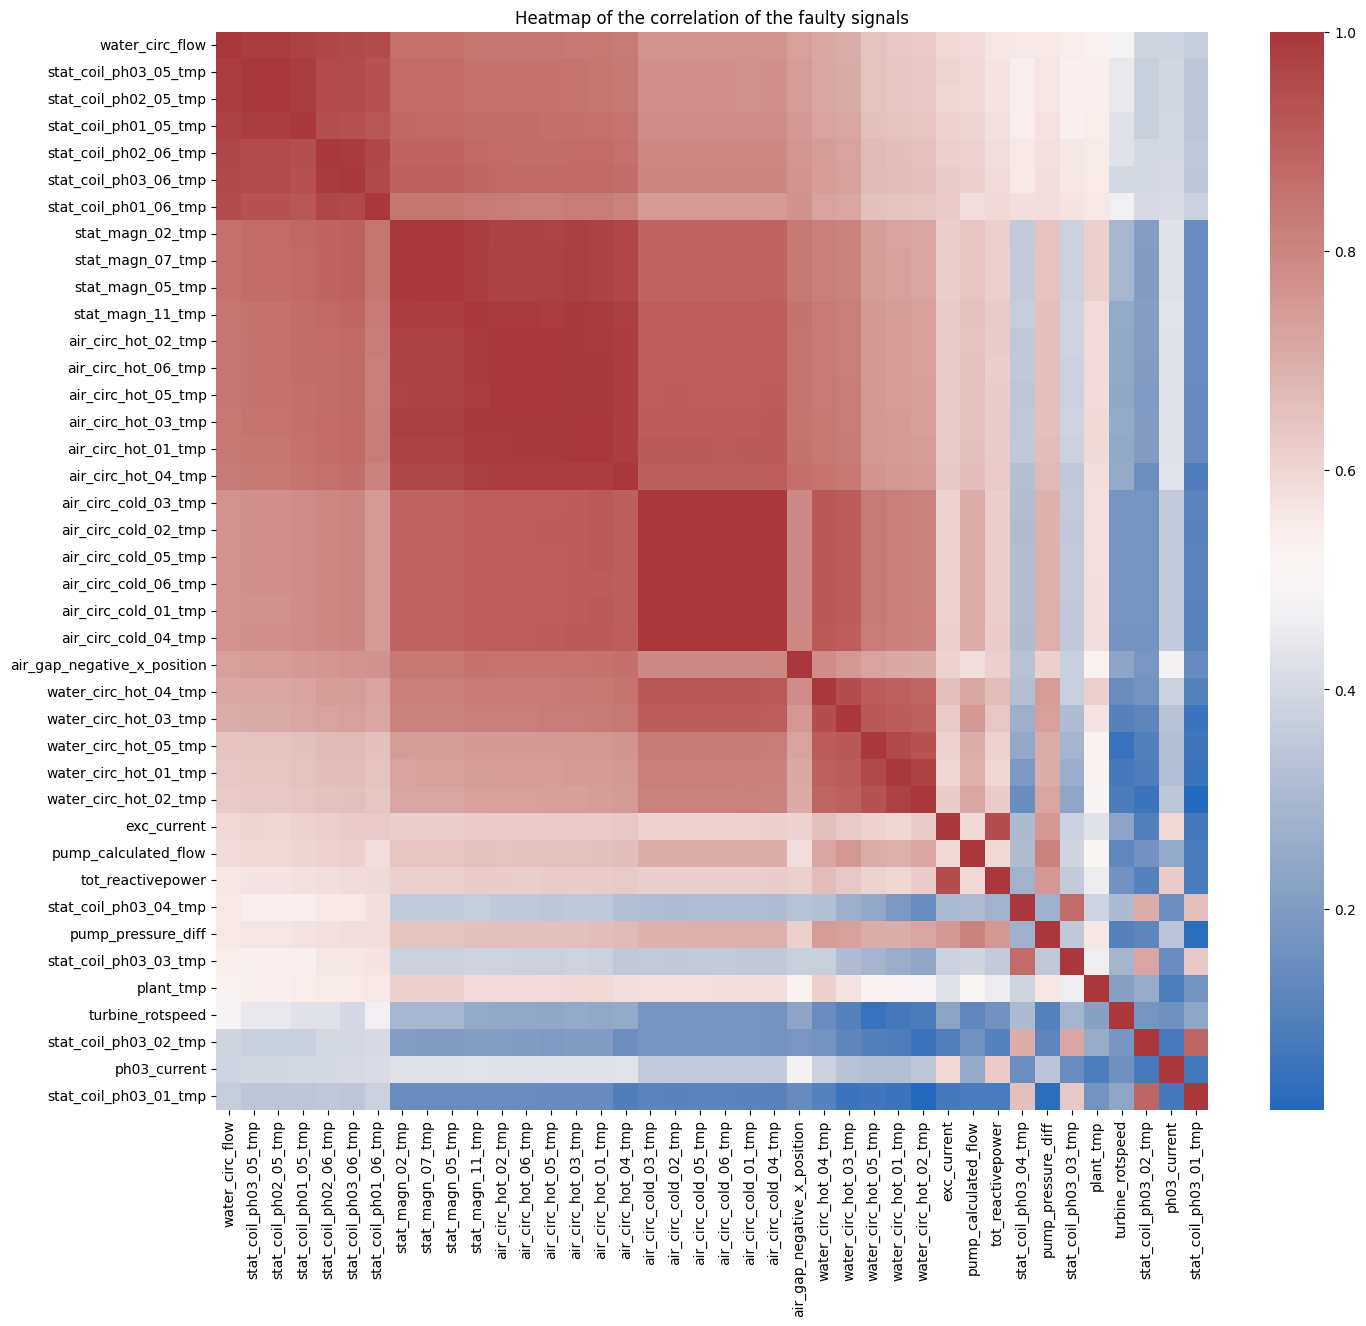

In [4]:
corr_faulty_df = correlation_faulty_signals(faulty_df, target_columns,"../images/corr_map_VG5_real_test_pump.pdf")

In [6]:
unique_correlated_names = find_unique_correlations(corr_faulty_df, 0.6)
print(np.array(unique_correlated_names))

['pump_calculated_flow' 'air_circ_cold_03_tmp' 'stat_magn_07_tmp'
 'air_circ_hot_04_tmp' 'air_circ_hot_03_tmp' 'stat_magn_05_tmp'
 'water_circ_flow' 'tot_reactivepower' 'water_circ_hot_03_tmp'
 'air_circ_cold_05_tmp' 'air_gap_negative_x_position'
 'air_circ_hot_06_tmp' 'water_circ_hot_04_tmp' 'stat_coil_ph03_01_tmp'
 'stat_coil_ph03_02_tmp' 'pump_pressure_diff' 'water_circ_hot_02_tmp'
 'stat_coil_ph02_06_tmp' 'stat_coil_ph01_06_tmp' 'stat_coil_ph03_03_tmp'
 'air_circ_hot_05_tmp' 'air_circ_hot_02_tmp' 'exc_current'
 'air_circ_cold_06_tmp' 'stat_coil_ph01_05_tmp' 'stat_magn_02_tmp'
 'stat_magn_11_tmp' 'stat_coil_ph03_06_tmp' 'plant_tmp'
 'stat_coil_ph02_05_tmp' 'air_circ_cold_01_tmp' 'water_circ_hot_05_tmp'
 'air_circ_hot_01_tmp' 'ph03_current' 'air_circ_cold_02_tmp'
 'stat_coil_ph03_05_tmp' 'stat_coil_ph03_04_tmp' 'air_circ_cold_04_tmp'
 'water_circ_hot_01_tmp']


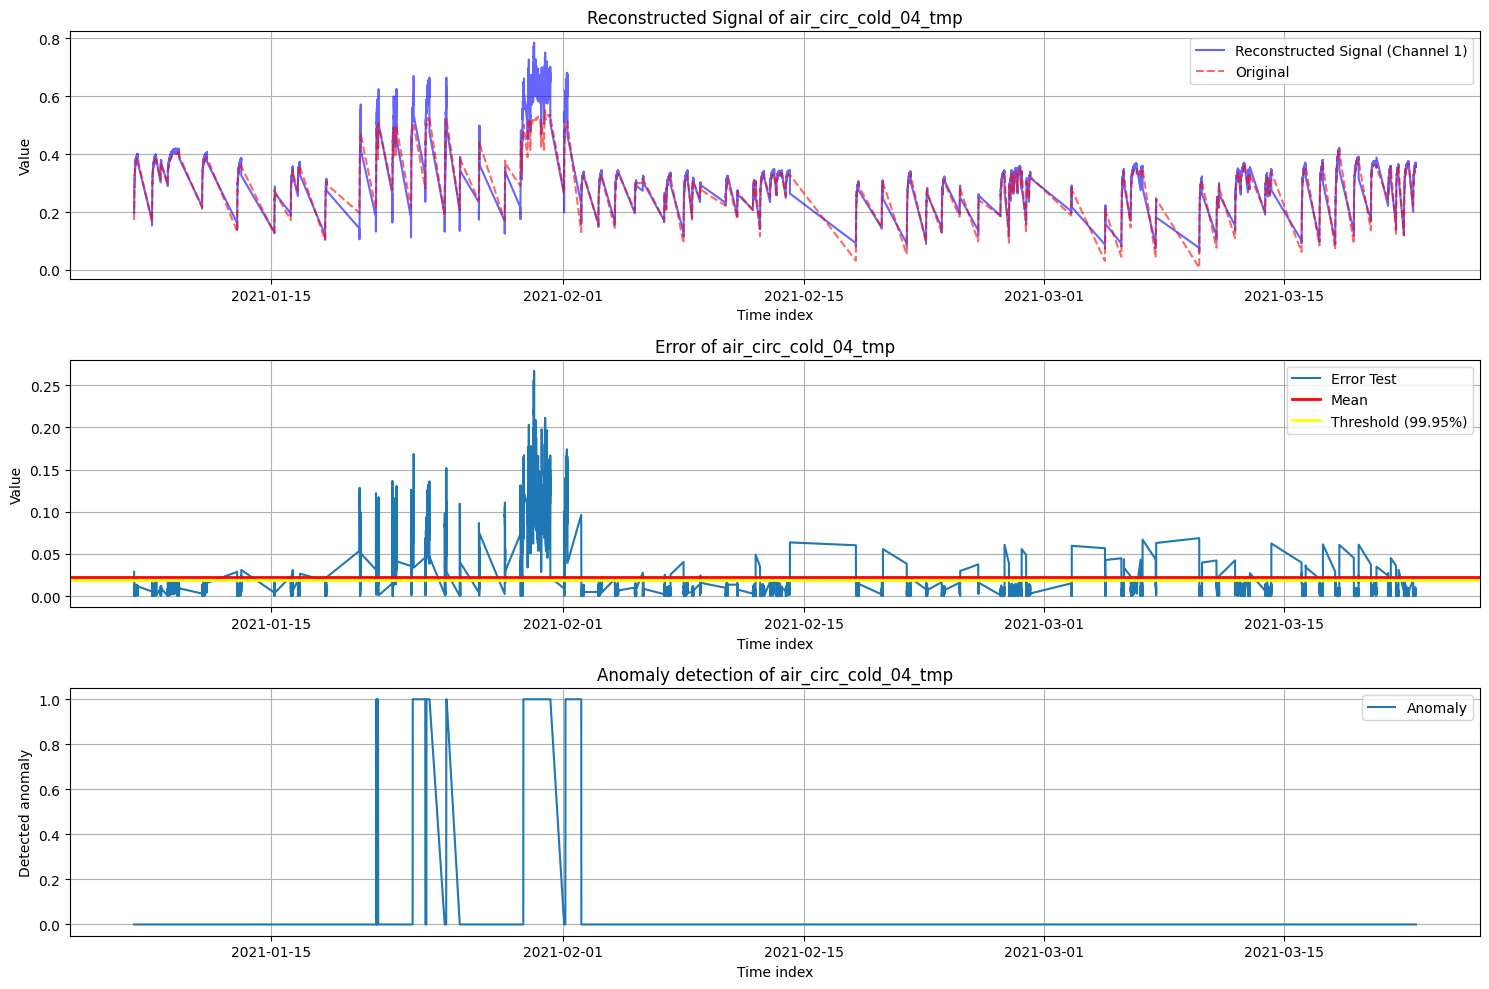

In [7]:
target_columns = unique_correlated_names
i=-2 # Change the value to change the column

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))

# First subplot
ax1.plot(reconstructed_test_df[target_columns[i]], label='Reconstructed Signal (Channel 1)', color='b', alpha=0.6)
ax1.plot(test_df[target_columns[i]], label="Original", color='r', linestyle='--', alpha=0.6)
ax1.set_xlabel('Time index')
ax1.set_ylabel('Value')
ax1.set_title(f'Reconstructed Signal of {target_columns[i]}')
ax1.grid()
ax1.legend()

# Second subplot
ax2.plot(error_test[target_columns[i]], label="Error Test")
ax2.axhline(np.mean(error_test[target_columns[i]]), color='red', linewidth=2, label="Mean")
threshold = threshold_df[target_columns[i]]
ax2.axhline(threshold, color='yellow', linewidth=2, label="Threshold (99.95%)")
ax2.set_xlabel('Time index')
ax2.set_ylabel('Value')
ax2.set_title(f'Error of {target_columns[i]}')
ax2.grid()
ax2.legend()

ax3.plot(faulty_df[target_columns[i]], label="Anomaly")
ax3.set_xlabel('Time index')
ax3.set_ylabel('Detected anomaly')
ax3.set_title(f'Anomaly detection of {target_columns[i]}')
ax3.grid()
ax3.legend()

plt.tight_layout()
plt.savefig("../images/failure_water_test_VG5_pump.pdf")
plt.show()

In [8]:
target_columns = ['water_circ_flow', 'tot_reactivepower', 'pump_calculated_flow', 'air_circ_hot_02_tmp',
                  'stat_coil_ph03_02_tmp', 'stat_magn_07_tmp']

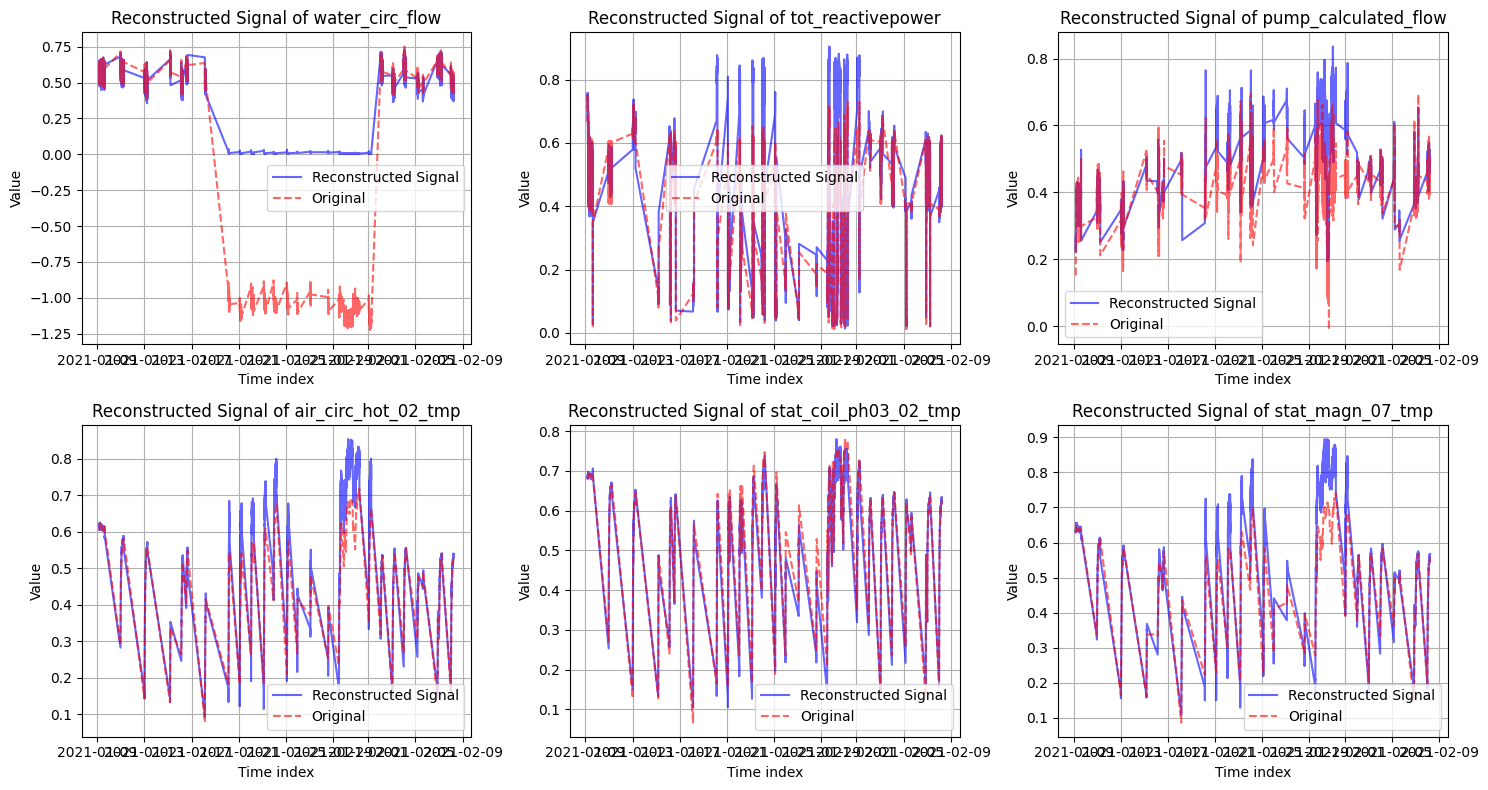

In [26]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i, column in enumerate(target_columns):
    row = i // 3
    col = i % 3

    # First subplot
    axs[row, col].plot(reconstructed_test_df[column][2000:16000], label='Reconstructed Signal', color='b', alpha=0.6)
    axs[row, col].plot(test_df[column][2000:16000], label="Original", color='r', linestyle='--', alpha=0.6)
    axs[row, col].set_xlabel('Time index')
    axs[row, col].set_ylabel('Value')
    axs[row, col].set_title(f'Reconstructed Signal of {column}')
    axs[row, col].grid()
    axs[row, col].legend()

# Hide any unused subplots
for j in range(len(target_columns), 6):
    row = j // 3
    col = j % 3
    fig.delaxes(axs[row, col])

plt.tight_layout()
plt.savefig(f"../images/anomaly_test_{unit}_{mode}.pdf")
plt.show()

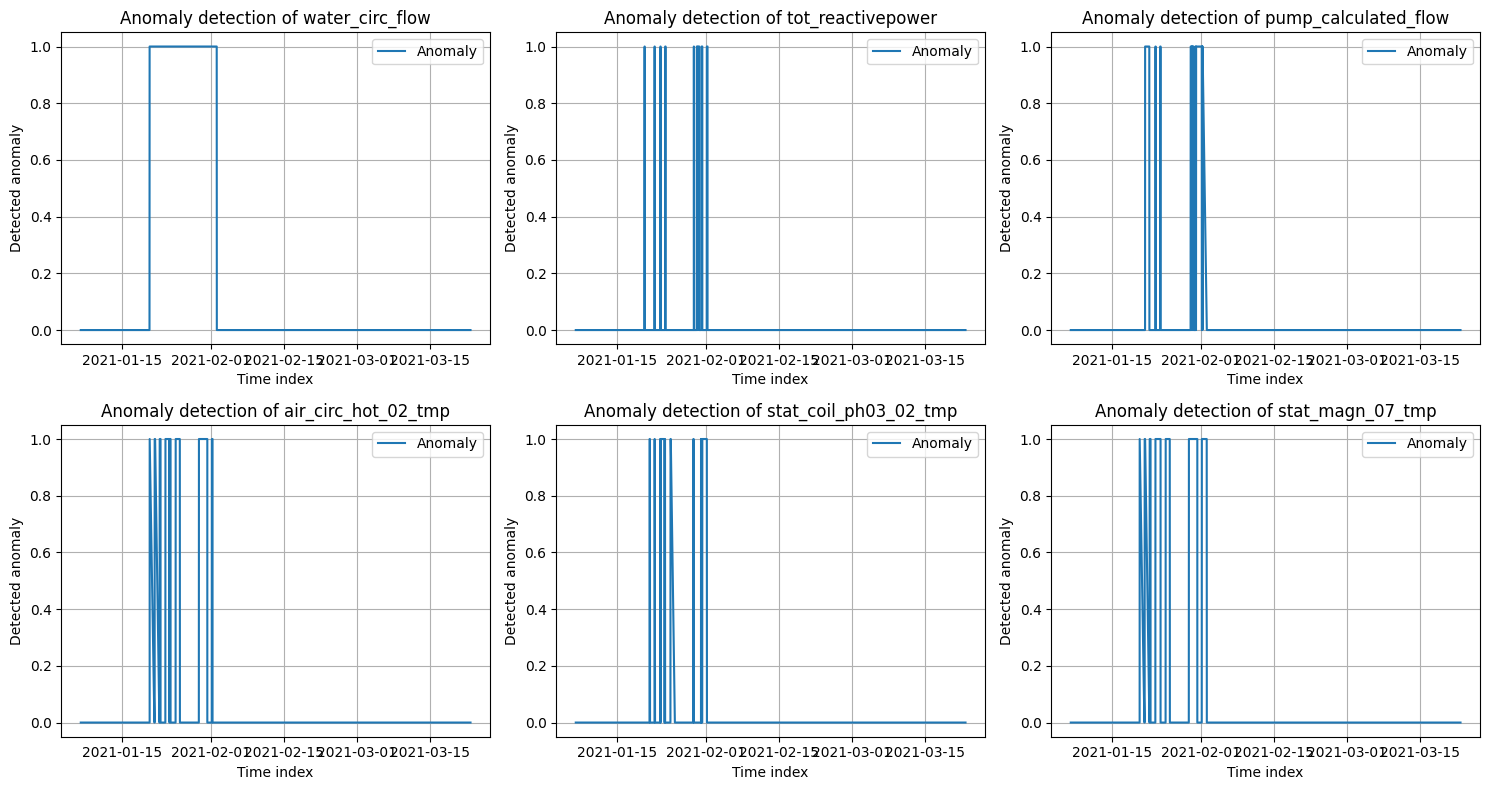

In [27]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i, column in enumerate(target_columns):
    row = i // 3
    col = i % 3

    # First subplot
    axs[row, col].plot(faulty_df[column], label="Anomaly")
    axs[row, col].set_xlabel('Time index')
    axs[row, col].set_ylabel('Detected anomaly')
    axs[row, col].set_title(f'Anomaly detection of {column}')
    axs[row, col].grid()
    axs[row, col].legend()


# Hide any unused subplots
for j in range(len(target_columns), 6):
    row = j // 3
    col = j % 3
    fig.delaxes(axs[row, col])

plt.tight_layout()
plt.savefig(f"../images/anomaly_label_{unit}_{mode}.pdf")
plt.show()

# Find anomalies on synthetic dataset

In [15]:
unit = "VG6"
mode ="turbine"

training_df = pd.read_parquet(f'data/training_{unit}_{mode}.parquet')

# Create dataset for evaluation
train_dataset = SlidingWindowDataset(
    training_df,
    window=DEFAULT_PARAMS['window_size'],
    device=device
)

# Create dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=DEFAULT_PARAMS['batch_size'],
    shuffle=False  # Important: keep order for anomaly detection
)

scaler, threshold_df, model = load_model(unit = unit, mode = mode)

/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/matthieu/Documents/ML predictive maintenance/Project/MLPM/SERVERFILES_CAE/findAnomalies.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that 

In [16]:
# LOAD PARAMETERS
SYNTHETIC_PARAMS = {
    'unit': unit,
    'test_set': '02',
    'anomaly_type': 'a',
    'set_type':'test_s02'
}

dataset_path = Path("../dataset")

rds_u5_buffer = RawDataset(dataset_path, "VG5", load_synthetic=False, load_training=False)

if mode=='turbine':
    turbine_or_pump=True
else: turbine_or_pump=False

test_syn_df = preprocess_hydraulic_synthetic_dataset(rds_train=rds_u5_buffer,
                                                     training_df=training_df, 
                                                     unit=SYNTHETIC_PARAMS["unit"],
                                                     number = SYNTHETIC_PARAMS["test_set"],
                                                     Type = SYNTHETIC_PARAMS["anomaly_type"],
                                                     scaler=scaler,
                                                     turbine_or_pump=turbine_or_pump)


# Getting the ground truth labels
ground_truth,_ = obtain_ground_truth(dataset_path, 
                                   unit = SYNTHETIC_PARAMS["unit"],
                                   test_set=SYNTHETIC_PARAMS["test_set"],
                                   anomaly_type=SYNTHETIC_PARAMS["anomaly_type"])
# Only keeping the correct labels
ground_truth = ground_truth[test_syn_df.index]

# Create dataset for evaluation
test_dataset = SlidingWindowDataset(
    test_syn_df,
    window=DEFAULT_PARAMS['window_size'],
    device=device
)

# Create dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size=DEFAULT_PARAMS['batch_size'],
    shuffle=False  # Important: keep order for anomaly detection
)


In [17]:
reconstructed_test_df = reconstruct_signal_from_windows(test_loader, test_syn_df, model, device)

Reconstructing signals:   0%|          | 0/217 [00:00<?, ?it/s]

Reconstructing signals: 100%|██████████| 217/217 [00:10<00:00, 20.64it/s]


In [18]:
error_test = compute_error(test_syn_df,reconstructed_test_df)

faulty_df = (error_test>threshold_df)
faulty_df = filter_faulty_df(faulty_df, 200)

faulty_signals_df = get_faulty_signals(faulty_df)

ind_fault = get_indexes_fault(faulty_df, column="stat_coil_ph03_05_tmp")

Processing columns: 100%|██████████| 84/84 [00:37<00:00,  2.23it/s]


In [19]:
target_columns = faulty_signals_df.head(10).index

print(target_columns)

Index(['water_circ_flow', 'stat_coil_ph01_04_tmp', 'water_circ_hot_03_tmp',
       'air_circ_cold_01_tmp', 'air_circ_cold_05_tmp', 'air_circ_hot_06_tmp',
       'air_circ_hot_02_tmp', 'stat_magn_02_tmp', 'water_circ_cold_tmp',
       'air_circ_cold_03_tmp'],
      dtype='object')


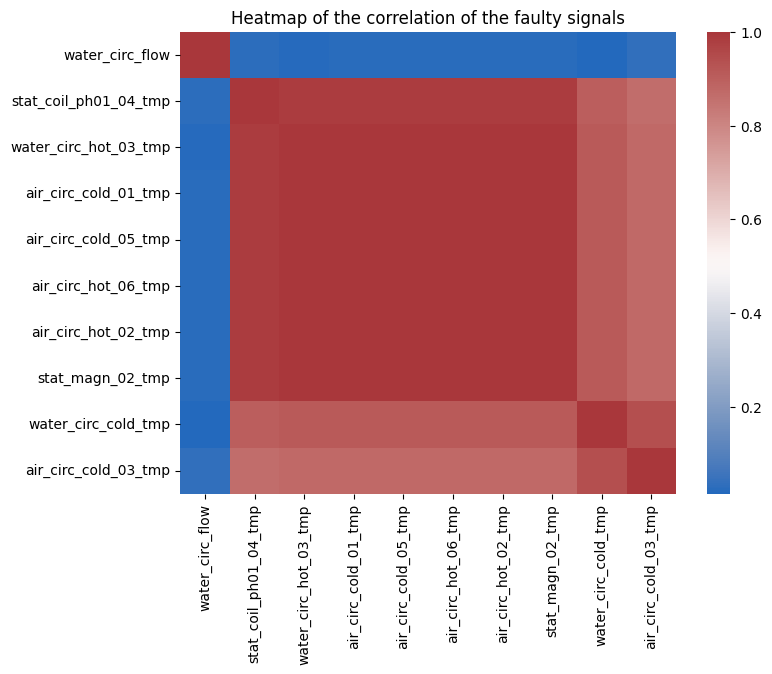

In [20]:
corr_faulty_df = correlation_faulty_signals(faulty_df, target_columns, 
                                            #f"../images/corr_map_syn_02_a_VG5_turbine.pdf"
                                            )

In [21]:
unique_correlated_names = find_unique_correlations(corr_faulty_df, 0.6)
print(unique_correlated_names)

['air_circ_cold_05_tmp', 'air_circ_hot_02_tmp', 'air_circ_hot_06_tmp', 'air_circ_cold_03_tmp', 'water_circ_hot_03_tmp', 'stat_magn_02_tmp', 'air_circ_cold_01_tmp', 'water_circ_cold_tmp', 'stat_coil_ph01_04_tmp']


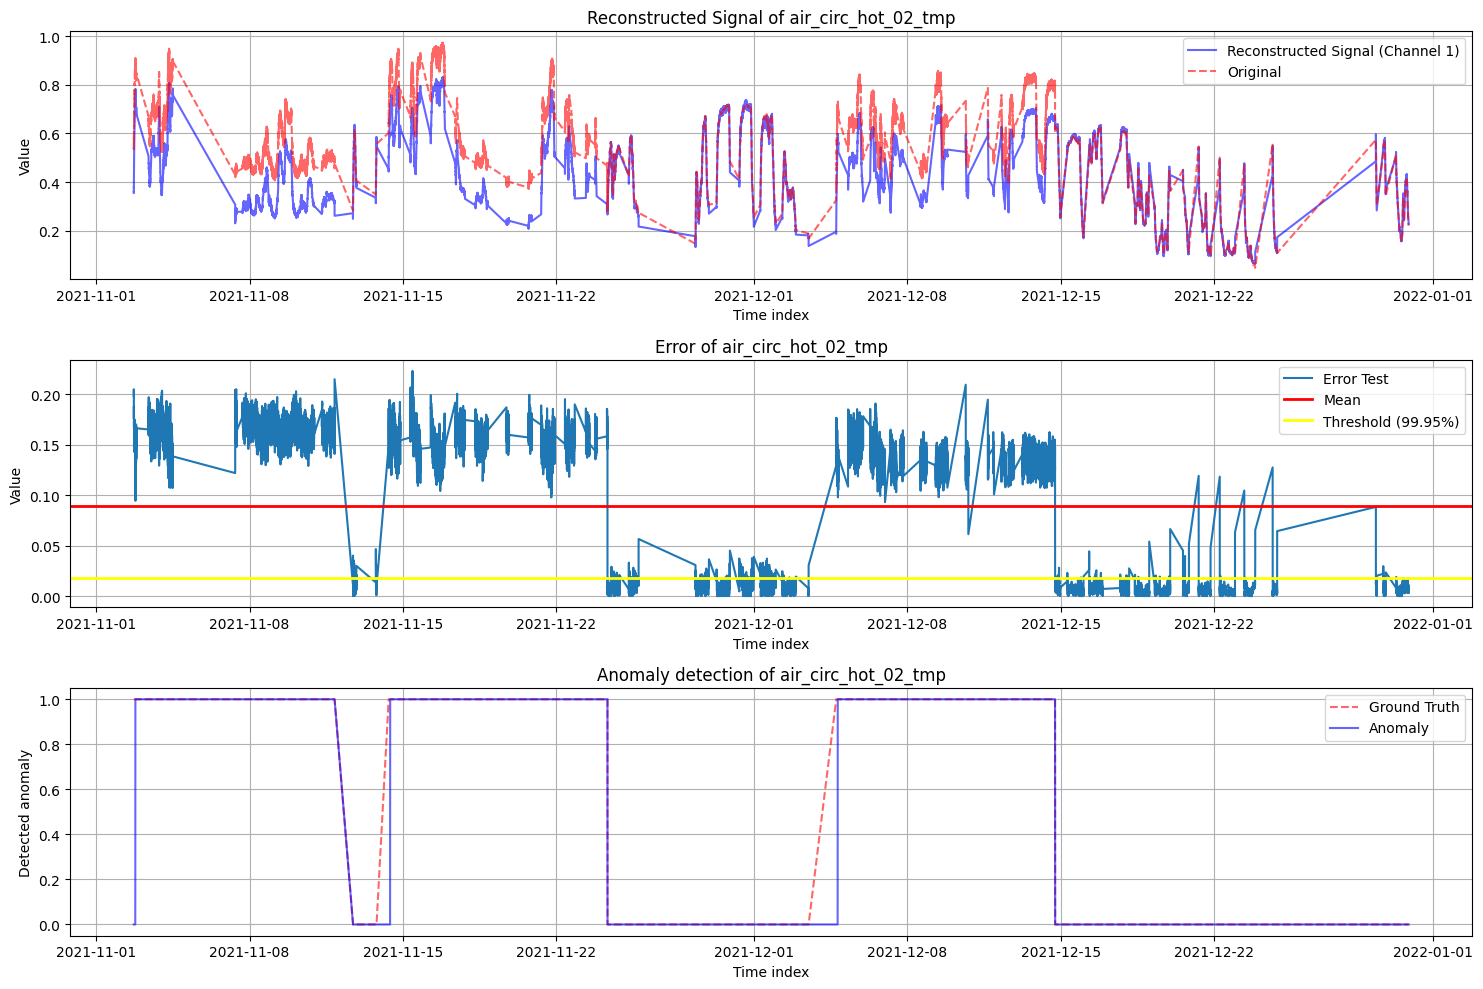

In [22]:
target_columns = unique_correlated_names
i=1 # Change the value to change the column

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))

# First subplot
ax1.plot(reconstructed_test_df[target_columns[i]], label='Reconstructed Signal (Channel 1)', color='b', alpha=0.6)
ax1.plot(test_syn_df[target_columns[i]], label="Original", color='r', linestyle='--', alpha=0.6)
ax1.set_xlabel('Time index')
ax1.set_ylabel('Value')
ax1.set_title(f'Reconstructed Signal of {target_columns[i]}')
ax1.grid()
ax1.legend()

# Second subplot
ax2.plot(error_test[target_columns[i]], label="Error Test")
ax2.axhline(np.mean(error_test[target_columns[i]]), color='red', linewidth=2, label="Mean")
threshold = threshold_df[target_columns[i]]
ax2.axhline(threshold, color='yellow', linewidth=2, label="Threshold (99.95%)")
ax2.set_xlabel('Time index')
ax2.set_ylabel('Value')
ax2.set_title(f'Error of {target_columns[i]}')
ax2.grid()
ax2.legend()

ax3.plot(ground_truth, label = "Ground Truth", color='r', linestyle='--', alpha=0.6)
ax3.plot(faulty_df[target_columns[i]], label="Anomaly", color='b', alpha=0.6)
ax3.set_xlabel('Time index')
ax3.set_ylabel('Detected anomaly')
ax3.set_title(f'Anomaly detection of {target_columns[i]}')
ax3.grid()
ax3.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_25536/1375796877.py:34: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


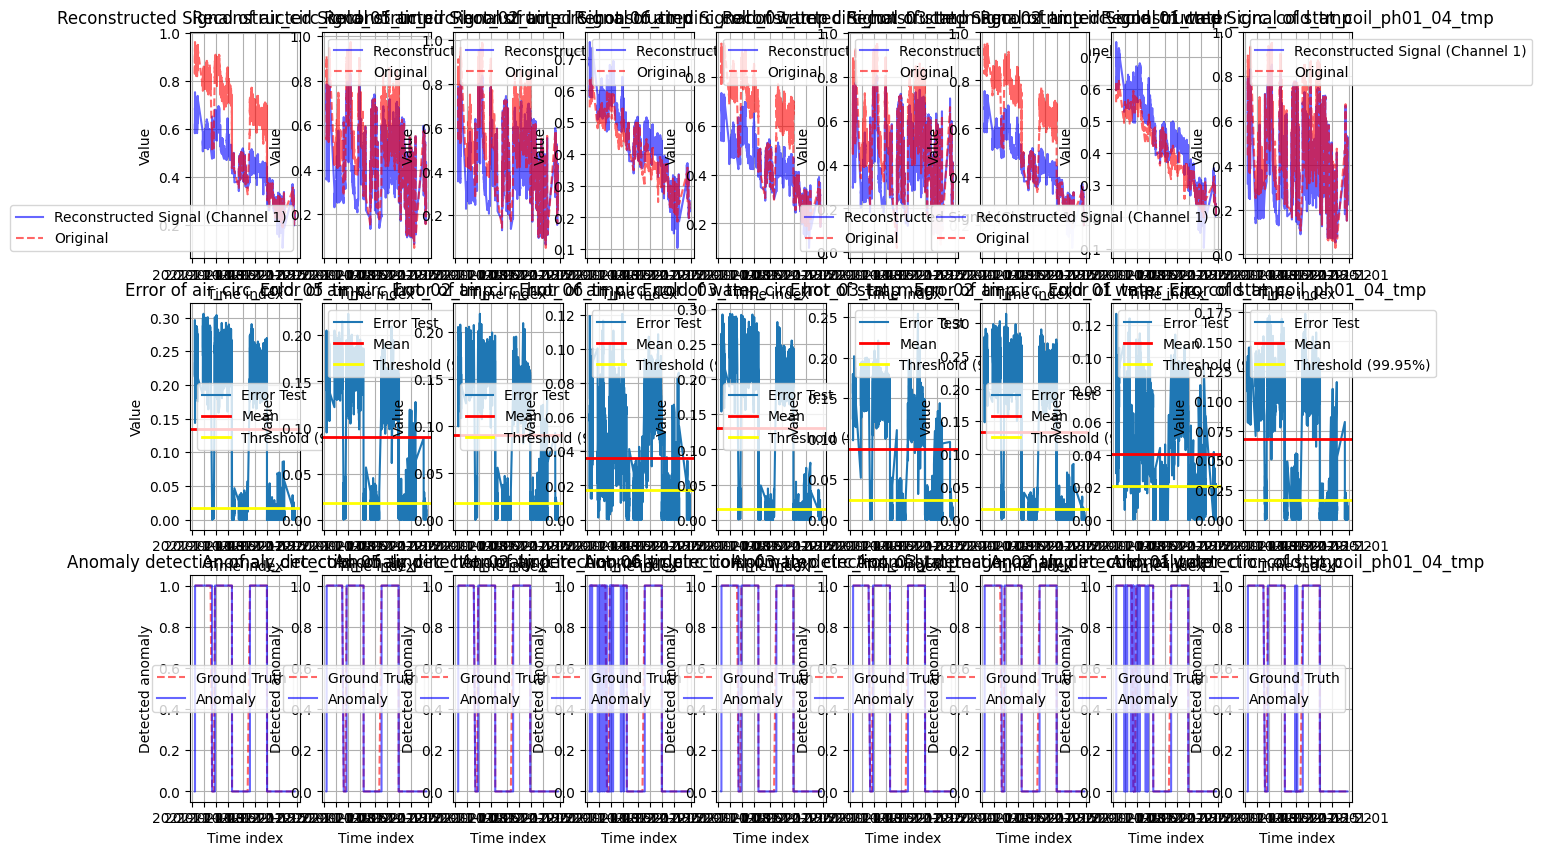

In [23]:
# Create a 3x3 subplot
fig, axs = plt.subplots(3, len(target_columns), figsize=(15, 10))

for i, column in enumerate(target_columns):
    # First subplot
    axs[0, i].plot(reconstructed_test_df[column], label='Reconstructed Signal (Channel 1)', color='b', alpha=0.6)
    axs[0, i].plot(test_syn_df[column], label="Original", color='r', linestyle='--', alpha=0.6)
    axs[0, i].set_xlabel('Time index')
    axs[0, i].set_ylabel('Value')
    axs[0, i].set_title(f'Reconstructed Signal of {column}')
    axs[0, i].grid()
    axs[0, i].legend()

    # Second subplot
    axs[1, i].plot(error_test[column], label="Error Test")
    axs[1, i].axhline(np.mean(error_test[column]), color='red', linewidth=2, label="Mean")
    threshold = threshold_df[column]
    axs[1, i].axhline(threshold, color='yellow', linewidth=2, label="Threshold (99.95%)")
    axs[1, i].set_xlabel('Time index')
    axs[1, i].set_ylabel('Value')
    axs[1, i].set_title(f'Error of {column}')
    axs[1, i].grid()
    axs[1, i].legend()

    # Third subplot
    axs[2, i].plot(ground_truth, label = "Ground Truth", color='r', linestyle='--', alpha=0.6)
    axs[2, i].plot(faulty_df[column], label="Anomaly", color='b', alpha=0.6)
    axs[2, i].set_xlabel('Time index')
    axs[2, i].set_ylabel('Detected anomaly')
    axs[2, i].set_title(f'Anomaly detection of {column}')
    axs[2, i].grid()
    axs[2, i].legend()

plt.tight_layout()
plt.savefig(f"../images/fault_syn_{unit}_{mode}.pdf")
plt.show()

In [24]:
anomaly_labels = faulty_df[target_columns[0]]

for column in target_columns:
    anomaly_labels &= faulty_df[column]

In [25]:
#anomaly_labels = faulty_df[target_columns[1]]
#
#for i in range(1,4):
#    anomaly_labels &= faulty_df[target_columns[i]]

In [26]:
# Compute ROC curve and find optimal threshold
fpr, tpr, thresholds = roc_curve(ground_truth[:-1], anomaly_labels)
roc_auc = auc(fpr, tpr)

# Compute confusion matrix
cm = confusion_matrix(ground_truth[:-1], anomaly_labels)

# Get classification report
report = classification_report(ground_truth[:-1], anomaly_labels)

results = {
        'roc_curve': (fpr, tpr, roc_auc),
        'confusion_matrix': cm,
        'classification_report': report
    }

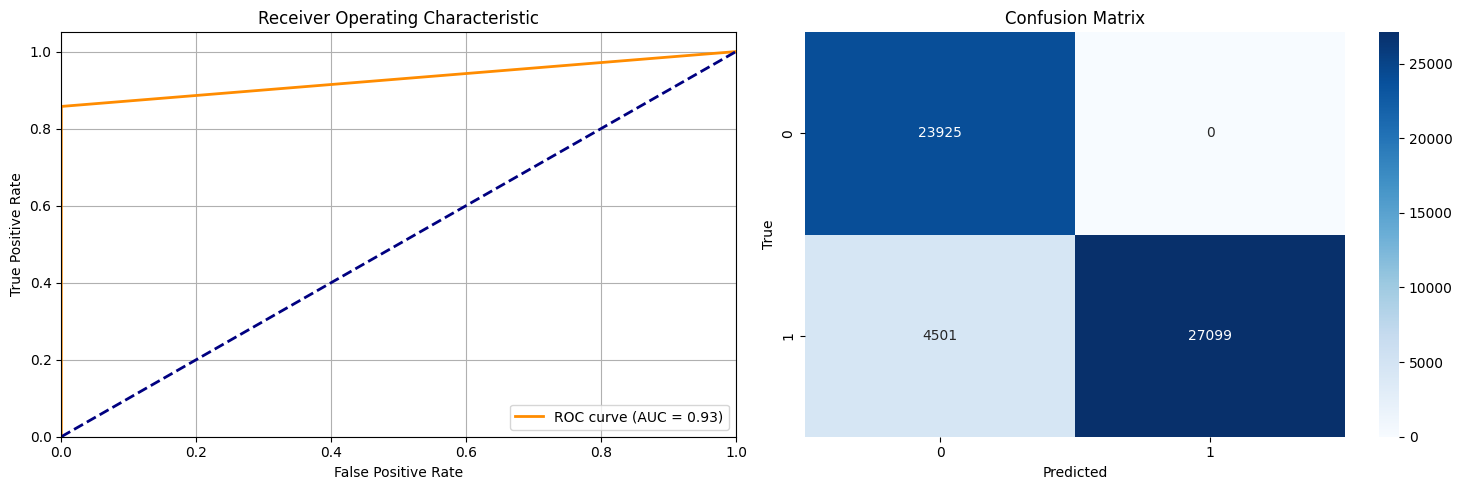


Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      1.00      0.91     23925
         1.0       1.00      0.86      0.92     31600

    accuracy                           0.92     55525
   macro avg       0.92      0.93      0.92     55525
weighted avg       0.93      0.92      0.92     55525



In [27]:
def plot_evaluation_results(results, unit=unit, mode=mode):
    """
    Plot evaluation results including ROC curves and confusion matrix.
    
    Args:
        results: dictionary containing evaluation results
        target_columns: list of column names with injected anomalies
    """
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot ROC curve
    fpr, tpr, roc_auc = results['roc_curve']
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('Receiver Operating Characteristic')
    ax1.legend(loc="lower right")
    ax1.grid(True)
    
    # Plot confusion matrix
    sns.heatmap(results['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_title('Confusion Matrix')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    
    plt.tight_layout()
    plt.savefig(f"../images/score_syn_{unit}_{mode}.pdf")
    plt.show()

    # Print classification report
    print("\nClassification Report:")
    print(results['classification_report'])
    

plot_evaluation_results(results)